# Exploratory Data Analysis (EDA)
Electricity Theft & Anomaly Detection

Objective:
- Understand consumption patterns
- Analyze class imbalance
- Detect abnormal behaviors
- Validate feature engineering


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()


,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,humidity,hour,day,month,day_of_week,load_ratio,rolling_mean_24h,rolling_std_24h
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,55.189874,0,1,1,0,0.030206,1.408501,0.000000
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,79.649722,1,1,1,0,0.032450,1.499701,0.128977
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,63.687502,2,1,1,0,0.030661,1.513077,0.094097
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,76.549985,3,1,1,0,0.022589,1.438621,0.167564
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,55.590191,4,1,1,0,0.039244,1.577163,0.342094


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)


Shape: (288000, 18)

Columns:
Index(['consumer_id', 'timestamp', 'kwh', 'voltage', 'current', 'power_factor',
       'theft_label', 'transformer_id', 'total_kwh', 'temperature', 'humidity',
       'hour', 'day', 'month', 'day_of_week', 'load_ratio', 'rolling_mean_24h',
       'rolling_std_24h'],
      dtype='str')


theft_label
0    287473
1       527
Name: count, dtype: int64


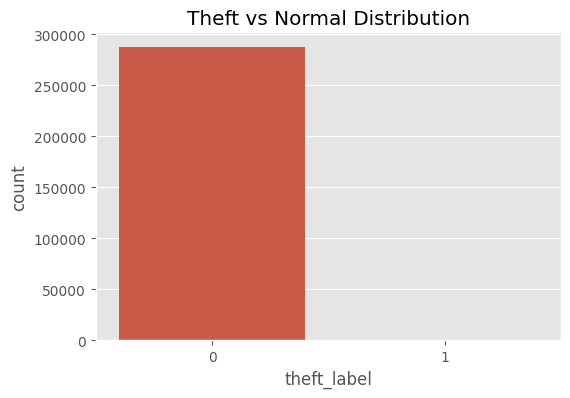

In [ ]:
theft_counts = df["theft_label"].value_counts()

print(theft_counts)

plt.figure(figsize=(6,4))
sns.countplot(x="theft_label", data=df)
plt.title("Theft vs Normal Distribution")
plt.show()


In [ ]:
theft_percentage = (theft_counts[1] / len(df)) * 100
print(f"Theft Percentage: {theft_percentage:.2f}%")


Theft Percentage: 0.18%


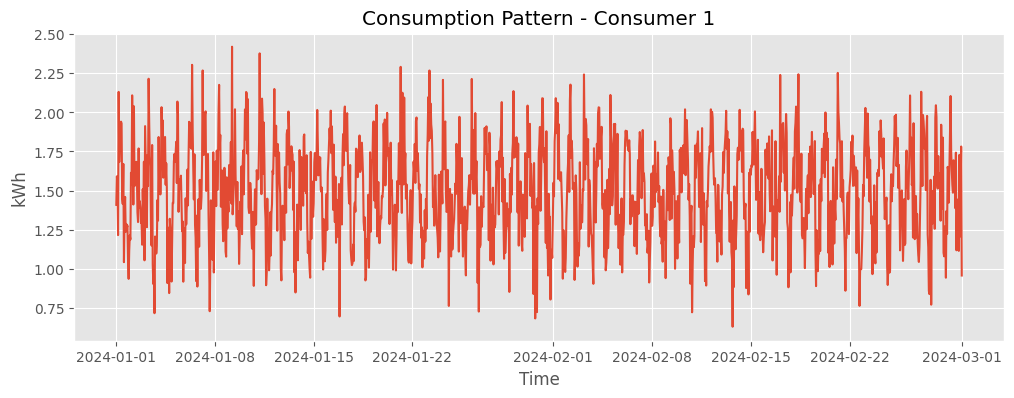

In [ ]:
sample_consumer = df["consumer_id"].iloc[0]

consumer_df = df[df["consumer_id"] == sample_consumer]

plt.figure(figsize=(12,4))
plt.plot(consumer_df["timestamp"], consumer_df["kwh"])
plt.title(f"Consumption Pattern - Consumer {sample_consumer}")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.show()


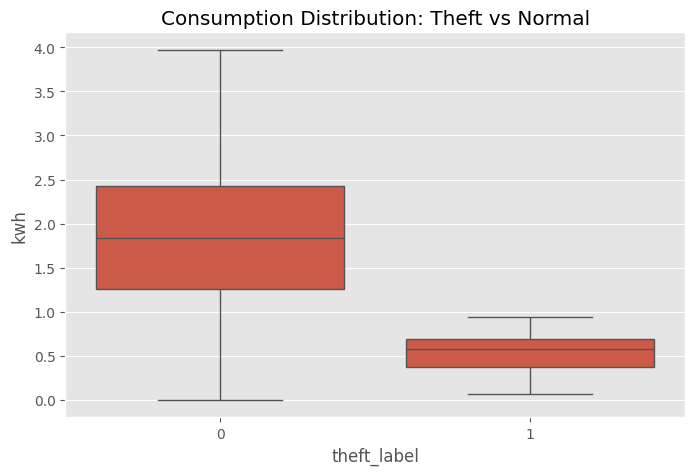

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="theft_label", y="kwh", data=df)
plt.title("Consumption Distribution: Theft vs Normal")
plt.show()


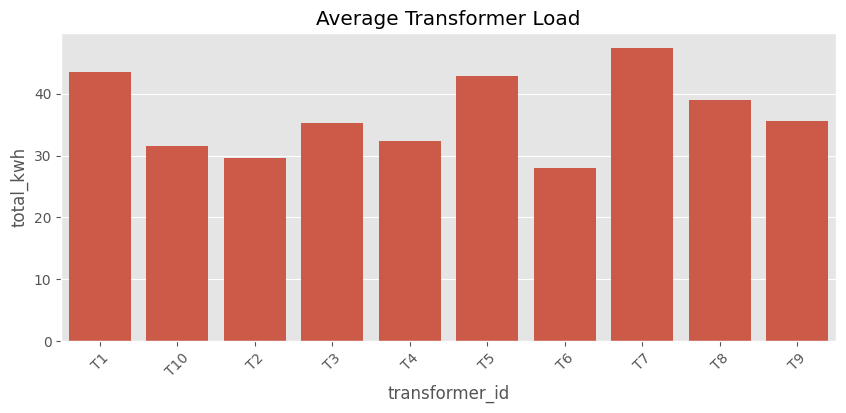

In [ ]:
transformer_load = df.groupby("transformer_id")["total_kwh"].mean().reset_index()

plt.figure(figsize=(10,4))
sns.barplot(x="transformer_id", y="total_kwh", data=transformer_load)
plt.title("Average Transformer Load")
plt.xticks(rotation=45)
plt.show()


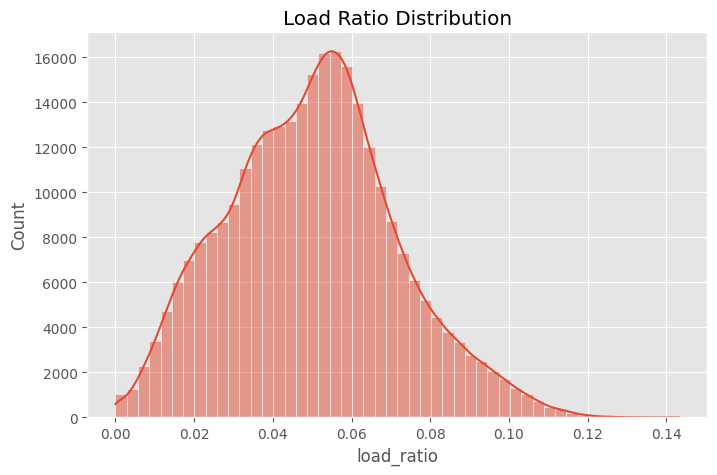

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["load_ratio"], bins=50, kde=True)
plt.title("Load Ratio Distribution")
plt.show()


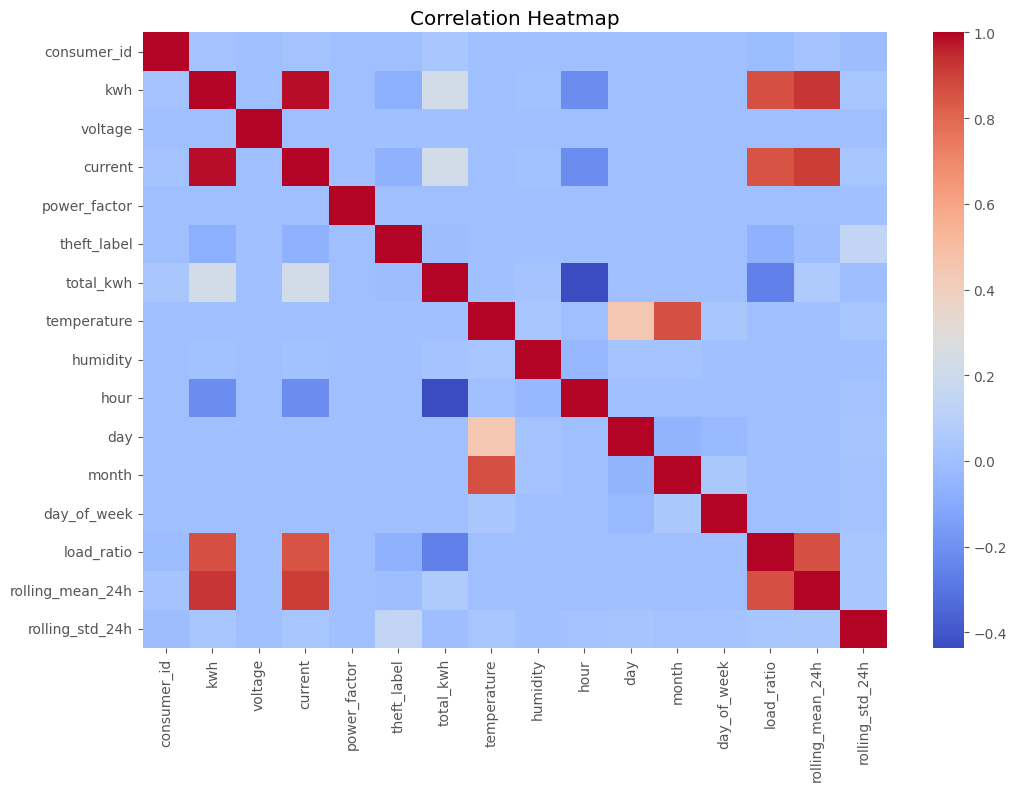

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


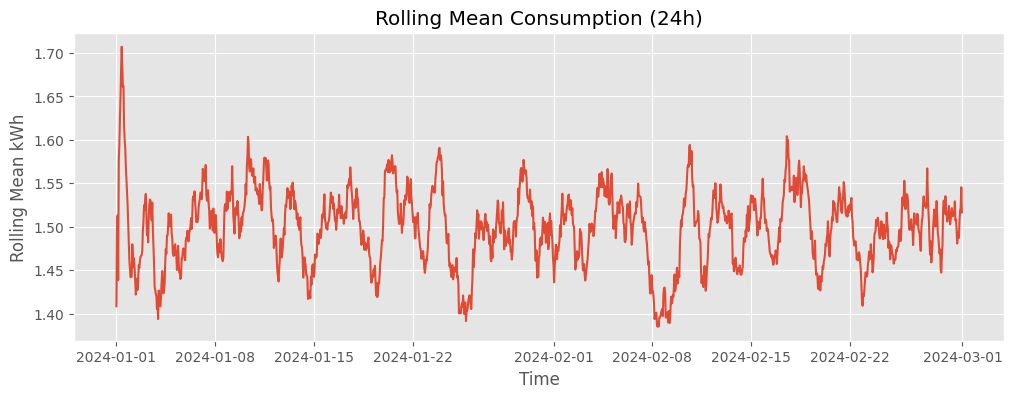

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(consumer_df["timestamp"], consumer_df["rolling_mean_24h"])
plt.title("Rolling Mean Consumption (24h)")
plt.xlabel("Time")
plt.ylabel("Rolling Mean kWh")
plt.show()


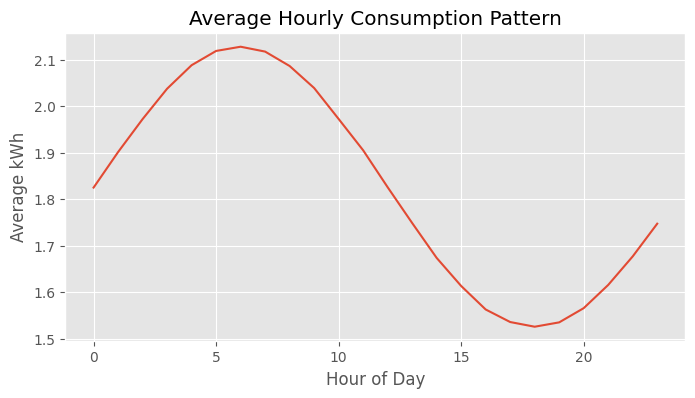

In [ ]:
hourly_pattern = df.groupby("hour")["kwh"].mean()

plt.figure(figsize=(8,4))
plt.plot(hourly_pattern.index, hourly_pattern.values)
plt.title("Average Hourly Consumption Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average kWh")
plt.show()


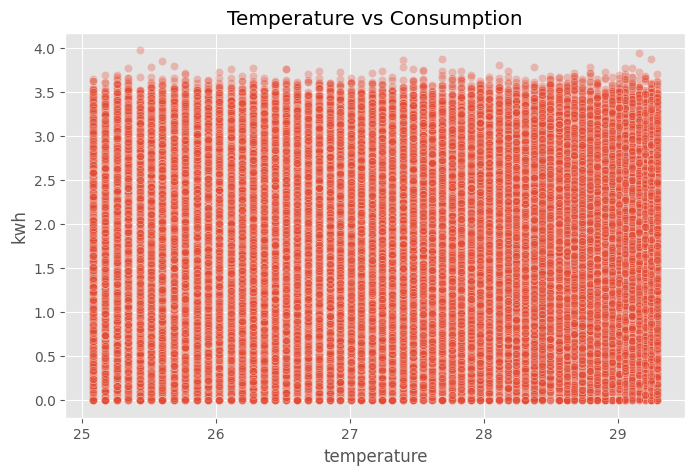

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="temperature", y="kwh", data=df, alpha=0.3)
plt.title("Temperature vs Consumption")
plt.show()


## Key Insights from EDA

1. Theft cases are highly imbalanced.
2. Consumption patterns show clear hourly seasonality.
3. Rolling statistics help detect sudden drops.
4. Load ratio feature can indicate abnormal transformer share.
5. Weather may influence consumption.

Next Step:
- Build Anomaly Detection Model
- Train Supervised Classifier
